In [2]:
from imports import *
from information_conditions import Information_Conditions
from base_ecopg import BaseEcologicalPublicGood
from helper_functions import *
from simulation_and_results_functions import *

['.']


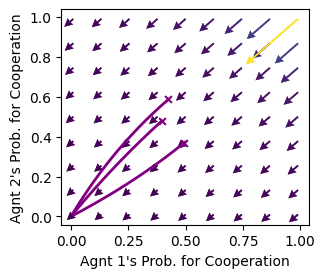

In [29]:
#| export
ecopg = BaseEcologicalPublicGood(m = -6.5)
ecopg_for_random_pts = Information_Conditions(ecopg, mode='ecological')
mae = POstratAC(env= ecopg_for_random_pts, learning_rates=0.05, discount_factors=0.975)
mae.random_softmax_strategy()
X_random_list = [mae.random_softmax_strategy() for _ in range(3)]
for mode in ['none']:
    #for each information condition get the average policy for the given observation set and plot the flow diagram

    ecopg = BaseEcologicalPublicGood(m = -6.5, degraded_choice= False)

    information_condition_instance = Information_Conditions(ecopg, mode=mode)
    num_observed_states = len(information_condition_instance.Oset[0])

    print(information_condition_instance.Oset[0])
    if mode == 'ecological' or mode == 'complete':
        x, y = ([0], list(range(1, num_observed_states, 2)), [0]), ([1], list(range(1, num_observed_states, 2)), [0])  
        mae1 = POstratAC(env=information_condition_instance, learning_rates=0.05, discount_factors=0.975)

        ax = fp.plot_strategy_flow(
            mae1,
            x, y, flowarrow_points=np.linspace(0.01, 0.99, 9), NrRandom=32,
            conds=np.array(information_condition_instance.Oset)[0, :num_observed_states],
        ) #skipping degraded states
    else:
        x, y = ([0], list(range(num_observed_states)), [0]), ([1], list(range(num_observed_states)), [0])
        mae1 = POstratAC(env=information_condition_instance, learning_rates=0.05, discount_factors=0.975)

        ax = fp.plot_strategy_flow(
            mae1,
            x, y, flowarrow_points=np.linspace(0.01, 0.99, 9), NrRandom=32,
            conds=np.array(information_condition_instance.Oset)[0, :num_observed_states],
        ) #skipping degraded states

    #add x and  y axis labeels

    ax[0].set_xlabel('Agnt 1\'s Prob. for Cooperation')
    ax[0].set_ylabel('Agnt 2\'s Prob. for Cooperation')

    for X_for_state_set in X_random_list:
        X_for_observation_set = average_policy_for_given_observation_set(X_for_state_set, information_condition_instance.O)
        xtraj, fixedpointreached = mae1.trajectory(X_for_observation_set, Tmax=10000, tolerance=1e-5)

        fp.plot_trajectories([xtraj], x, y, cols=['purple'], axes = ax)





['.']
[<Axes: >]


Text(0, 0.5, "Agnt 2's Prob. for Cooperation")

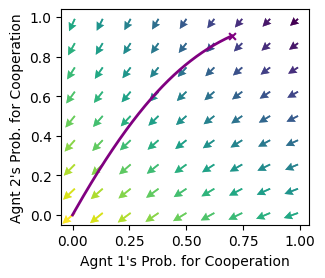

In [11]:
env_socdi = SocialDilemma(R=0.8, T=1, S=-0.5, P= 0)



    # x, y = ([0], list(range(1, num_observed_states, 2)), [0]), ([1], list(range(1, num_observed_states, 2)), [0])   #skipping degraded states
x, y = ([0], list(range(1)), [0]), ([1], list(range(1)), [0])
mae_env_memo1pd = stratAC(env=env_socdi, learning_rates=0.05, discount_factors=0.975)
X_random_list = [mae_env_memo1pd.random_softmax_strategy() for _ in range(1)]

X = mae_env_memo1pd.random_softmax_strategy()
print(env_socdi.Sset)



ax = fp.plot_strategy_flow(
    mae_env_memo1pd,
    x, y, flowarrow_points=np.linspace(0.01, 0.99, 9)
)

for X in X_random_list:
    xtraj, fixedpointreached = mae_env_memo1pd.trajectory(X, Tmax=10000, tolerance=1e-5)

    fp.plot_trajectories([xtraj], x, y, cols=['purple'], axes = ax)


print(ax)
#add x and y axis labels.
ax[0].set_xlabel('Agnt 1\'s Prob. for Cooperation')
ax[0].set_ylabel('Agnt 2\'s Prob. for Cooperation')


['c,c,.|', 'c,d,.|', 'd,c,.|', 'd,d,.|']


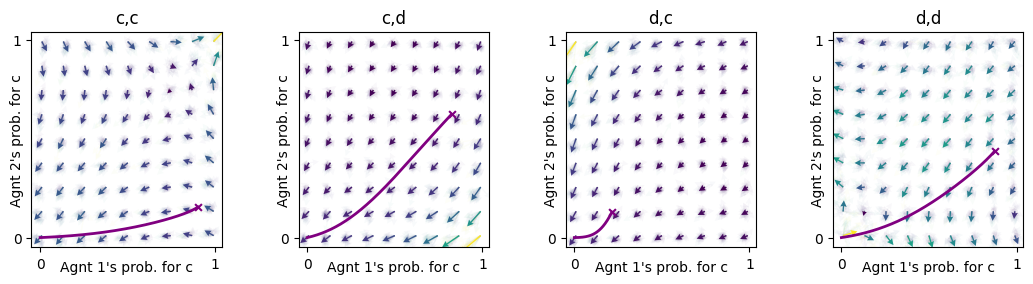

In [10]:
env_socdi = SocialDilemma(R=0.8, T=1, S=-0.5, P= 0)
env_memo1pd = HistoryEmbedded(env_socdi, h=(1,1,1))



    # x, y = ([0], list(range(1, num_observed_states, 2)), [0]), ([1], list(range(1, num_observed_states, 2)), [0])   #skipping degraded states
x, y = ([0], list(range(4)), [0]), ([1], list(range(4)), [0])
mae_env_memo1pd = stratAC(env=env_memo1pd, learning_rates=0.05, discount_factors=0.975)
X_random_list = [mae_env_memo1pd.random_softmax_strategy() for _ in range(1)]

X = mae_env_memo1pd.random_softmax_strategy()
print(env_memo1pd.Sset)



ax = fp.plot_strategy_flow(
    mae_env_memo1pd,
    x, y, flowarrow_points=np.linspace(0.01, 0.99, 9), NrRandom=32,
    conds=np.array(['c,c', 'c,d', 'd,c', 'd,d'])[0 : len(env_memo1pd.Sset)],
)

for X in X_random_list:
    xtraj, fixedpointreached = mae_env_memo1pd.trajectory(X, Tmax=10000, tolerance=1e-5)

    fp.plot_trajectories([xtraj], x, y, cols=['purple'], axes = ax)



[[[0.999 0.001]]

 [[0.001 0.999]]]
[0.999 0.001] [0.001 0.999]


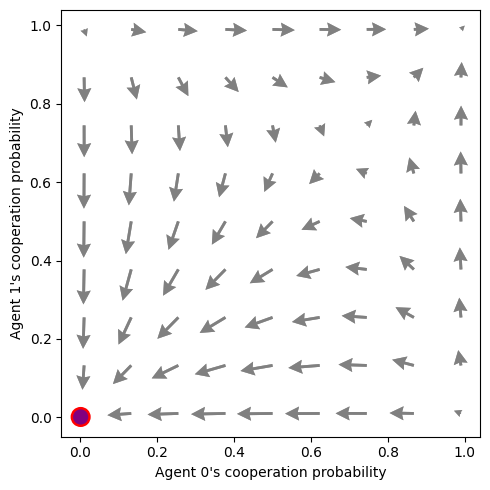

In [6]:
from pyCRLD.Agents.StrategyActorCritic import stratAC
from pyCRLD.Environments.SocialDilemma import SocialDilemma
from pyCRLD.Utils import FlowPlot as fp

import numpy as np
import matplotlib.pyplot as plt

# --- Initialize environment and agents ---
env = SocialDilemma(R=1.0, T=0.8, S=-0.5, P=0.0)
mae = stratAC(env=env, learning_rates=0.1, discount_factors=0.9)

# --- Compute learning trajectory ---
# np.random.seed(0)
x0 = mae.random_softmax_strategy()
x1 = np.array([[[0.001, 0.999]],
               [[0.001,  0.999]]])  # shape (2,1,2)

x2 = np.array([[[0.999, 0.001]],
               [[0.001,  0.999]]])  # shape (2,1,2)

print(x2)  # random initial strategy





xtraj, fixedpointreached = mae.trajectory(x1, Tmax=10000, tolerance=1e-5)

# --- Plot only the phase portrait ---
fig, ax = plt.subplots(figsize=(5, 5))

x = ([0], [0], [0])
y = ([1], [0], [0])

fp.plot_strategy_flow(mae, x, y,
                      use_RPEarrows=False,
                      flowarrow_points=np.linspace(0.01, 0.99, 9),
                      axes=[ax],
                      col = 'grey')
fp.plot_trajectories([xtraj], x, y, cols=['purple'], axes=[ax])

print(x2[0, 0], x2[1, 0])

plt.scatter(x1[0,0, 0], x1[1,0,0], facecolors='none', edgecolors='red', s=120, linewidths=3.5, label='Initial Strategy')
plt.scatter(x1[0,0, 0], x1[1,0,0], facecolors='purple', edgecolors='none', s=120, linewidths=3.5, label='Initial Strategy')


ax.set_xlabel("Agent 0's cooperation probability")
ax.set_ylabel("Agent 1's cooperation probability")


plt.tight_layout()
plt.show()
